<div style="background: linear-gradient(135deg, #0f172a 0%, #1e293b 45%, #334155 100%); padding: 28px 32px; border-radius: 18px; margin-bottom: 18px;">
  <div style="font-size: 12px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 8px; color: #f8fafc;">
    Titanic Competition
  </div>
  <h1 style="margin: 0 0 14px 0; font-size: 34px; color: #f8fafc;">
    Titanic | Social Patterns, EDA &amp; Survival Modeling
  </h1>
  <p style="margin: 0; font-size: 16px; line-height: 1.7; color: #e2e8f0; max-width: 980px;">
    Survival on the Titanic was not shaped by a single rule. This study follows the interaction between social status, family structure, cabin signal, fare, and ticket-level group behavior to understand why some passenger profiles were systematically more likely to survive than others.
  </p>
</div>

![RMS Titanic](https://commons.wikimedia.org/wiki/Special:FilePath/RMS%20Titanic.jpg)

<table style="width:100%; border-collapse:separate; border-spacing:12px 12px;">
  <tr>
    <td style="background:#eff6ff; padding:18px; border-radius:14px; vertical-align:top; width:33%;">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:1px; color:#1d4ed8; margin-bottom:6px;"><b>Lens 1</b></div>
      <div style="font-size:18px; margin-bottom:6px;"><b>Social position</b></div>
      <div>Passenger class, titles, deck, and cabin availability as signals of status and access.</div>
    </td>
    <td style="background:#f8fafc; padding:18px; border-radius:14px; vertical-align:top; width:33%;">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:1px; color:#475569; margin-bottom:6px;"><b>Lens 2</b></div>
      <div style="font-size:18px; margin-bottom:6px;"><b>Travel structure</b></div>
      <div>Family size, ticket groups, and surname groups as proxies for coordination and shared movement.</div>
    </td>
    <td style="background:#fef3c7; padding:18px; border-radius:14px; vertical-align:top; width:33%;">
      <div style="font-size:12px; text-transform:uppercase; letter-spacing:1px; color:#b45309; margin-bottom:6px;"><b>Lens 3</b></div>
      <div style="font-size:18px; margin-bottom:6px;"><b>Decision context</b></div>
      <div>How age, sex, fare, and embarkation interact with class instead of acting alone.</div>
    </td>
  </tr>
</table>

<div style="background:#f8fafc; padding:18px 22px; border-left:6px solid #0f172a; border-radius:12px; margin-top:8px;">
  <div style="font-size:18px; margin-bottom:8px;"><b>Guiding questions</b></div>
  <ul style="margin:0 0 0 18px;">
    <li>Which passenger groups had structural advantages during evacuation?</li>
    <li>Which hidden signals improve prediction beyond the classic baseline of sex and class?</li>
    <li>How much information can be recovered from names, tickets, cabins, and group patterns?</li>
  </ul>
</div>

## Roadmap

1. Data loading and first data-quality checks  
2. Hypothesis-driven EDA with targeted visualizations  
3. Feature engineering based on the observed patterns  
4. Leakage-safe group priors  
5. Model comparison, blending, and interpretation  
6. Error analysis and final conclusions

In [1]:
# =========================
# 1. Imports and settings
# =========================
import re
import warnings
from itertools import product

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42

In [2]:
# =========================
# 2. Load data
# =========================
TRAIN_PATH = "/kaggle/input/competitions/titanic/train.csv"
TEST_PATH = "/kaggle/input/competitions/titanic/test.csv"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head())

Train shape: (891, 12)
Test shape : (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S


<div style="border-top: 3px solid #0f172a; padding-top: 14px; margin-top: 4px;"></div>

## 1. Problem definition

The target is **`Survived`**, and the evaluation metric is **classification accuracy**.

The analytical task is simple on the surface and much richer underneath:

> Which passenger attributes help separate those who survived from those who did not, while avoiding noisy shortcuts and information leakage?

That framing encourages two parallel goals:
- read the table as a historical record of social structure and movement;
- convert those patterns into robust predictive features.

In [3]:
# =========================
# 3. Quick audit
# =========================
audit = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "missing": train.isna().sum(),
    "missing_pct": train.isna().mean().mul(100).round(2),
    "nunique": train.nunique()
}).sort_values(["missing", "nunique"], ascending=[False, False])

display(audit)
print("\nTarget distribution:")
display(train["Survived"].value_counts(normalize=True).rename("share").mul(100).round(2))

,dtype,missing,missing_pct,nunique
Cabin,object,687,77.1000,147
Age,float64,177,19.8700,88
Embarked,object,2,0.2200,3
PassengerId,int64,0,0.0000,891
Name,object,0,0.0000,891
Ticket,object,0,0.0000,681
Fare,float64,0,0.0000,248
SibSp,int64,0,0.0000,7
Parch,int64,0,0.0000,7
Pclass,int64,0,0.0000,3



Target distribution:


Survived
0   61.6200
1   38.3800
Name: share, dtype: float64

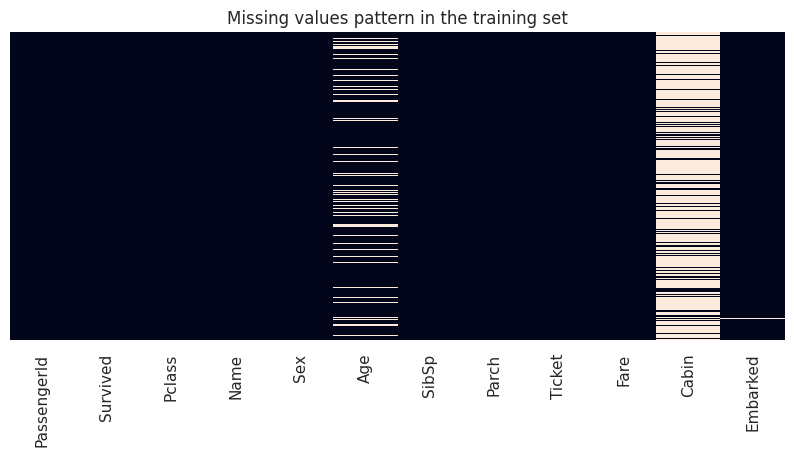

In [4]:
# Visual overview of missingness
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(train.isna(), cbar=False, yticklabels=False, ax=ax)
ax.set_title("Missing values pattern in the training set")
plt.show()

<div style="background:#f8fafc; padding:18px 22px; border-radius:14px; border:1px solid #e5e7eb;">

## 2. First takeaways

Even before modeling, several structural facts stand out:

- `Cabin` is sparse, but sparse does not mean useless — the very presence of cabin information may itself be informative.
- `Age` is incomplete, so imputation should respect social context such as sex, class, and title.
- `Name` looks unstructured, but it contains titles and surnames that can be transformed into usable signals.
- `Ticket` may capture group travel and booking structure.
- `Fare` is not just a numeric value; it is tied to class, group booking behavior, and possibly boarding conditions.

These observations motivate a deliberately hypothesis-driven EDA rather than a generic chart-by-chart pass.
</div>

<div style="border-top: 3px solid #0f172a; padding-top: 14px; margin-top: 4px;"></div>

## 3. Hypothesis-driven EDA

The EDA starts from a set of concrete hypotheses rather than from isolated variables:

1. Survival was not only about gender; it was filtered through **class**.  
2. **Titles** compress social information hidden inside names.  
3. **Family size** matters, but not linearly.  
4. **Cabin and deck** act as partial proxies for wealth and ship location.  
5. **Age** changes the effect of class and sex rather than acting independently.  
6. **Shared tickets** may reveal travel groups whose outcomes were correlated.

The following sections test these ideas one by one.

In [5]:
# Helper column for early EDA
eda = train.copy()

eda["FamilySize"] = eda["SibSp"] + eda["Parch"] + 1
eda["IsAlone"] = (eda["FamilySize"] == 1).astype(int)

def extract_title(name):
    match = re.search(r",\s*([^\.]+)\.", str(name))
    return match.group(1).strip() if match else "Unknown"

eda["TitleRaw"] = eda["Name"].apply(extract_title)

title_map = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Royalty", "Countess": "Royalty", "Sir": "Royalty",
    "Don": "Royalty", "Dona": "Royalty", "Jonkheer": "Royalty",
    "Capt": "Officer", "Col": "Officer", "Major": "Officer",
    "Dr": "Officer", "Rev": "Officer"
}

eda["Title"] = eda["TitleRaw"].replace(title_map)
eda["Title"] = eda["Title"].where(
    eda["Title"].isin(["Mr", "Mrs", "Miss", "Master", "Officer", "Royalty"]),
    "Rare"
)

eda["HasCabin"] = eda["Cabin"].notna().astype(int)
eda["Deck"] = eda["Cabin"].fillna("U").astype(str).str[0]

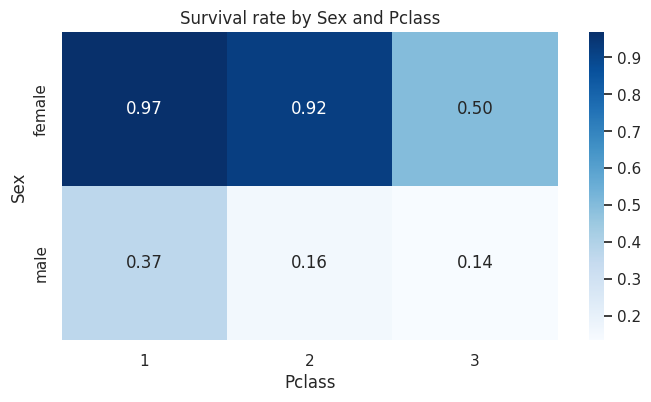

In [6]:
# Survival by Sex x Pclass
pivot = pd.pivot_table(
    eda,
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Survival rate by Sex and Pclass")
plt.show()

,passengers,survival_rate,median_age
Title,,,
Rare,1,1.0000,33.0000
Mrs,126,0.7937,35.0000
Miss,185,0.7027,21.0000
Master,40,0.5750,3.5000
Royalty,4,0.5000,44.0000
Officer,18,0.2778,50.0000
Mr,517,0.1567,30.0000


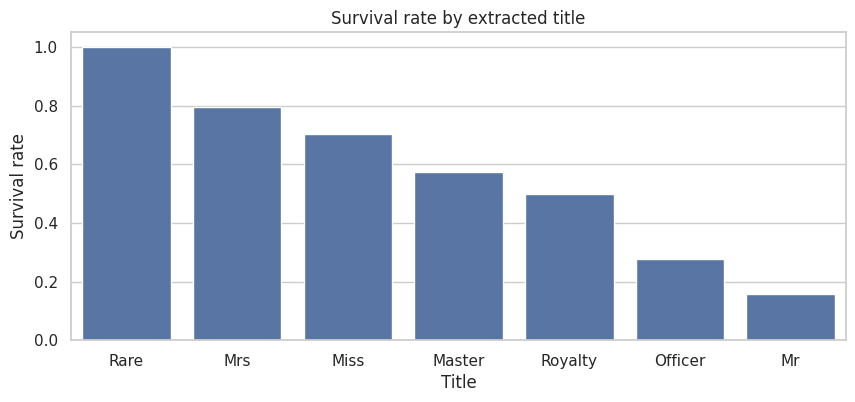

In [7]:
# Title-level survival
title_stats = (
    eda.groupby("Title")
       .agg(passengers=("PassengerId", "count"),
            survival_rate=("Survived", "mean"),
            median_age=("Age", "median"))
       .sort_values("survival_rate", ascending=False)
)

display(title_stats)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=title_stats.reset_index(), x="Title", y="survival_rate", ax=ax)
ax.set_title("Survival rate by extracted title")
ax.set_ylabel("Survival rate")
plt.xticks(rotation=0)
plt.show()

,FamilySize,passengers,survival_rate
0,1,537,0.3035
1,2,161,0.5528
2,3,102,0.5784
3,4,29,0.7241
4,5,15,0.2000
5,6,22,0.1364
6,7,12,0.3333
7,8,6,0.0000
8,11,7,0.0000


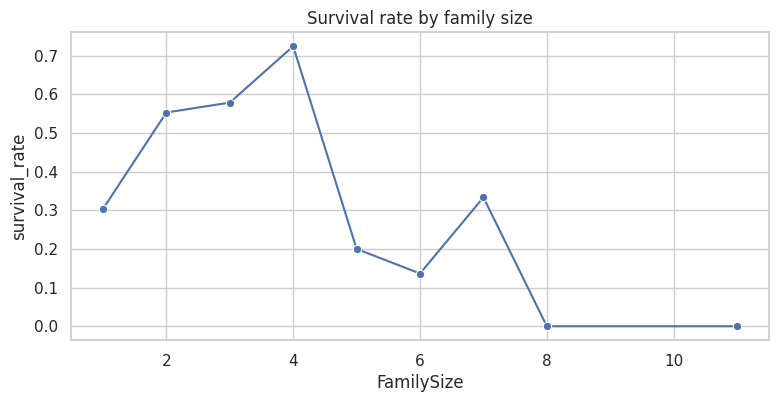

In [8]:
# Family size effect
family_stats = (
    eda.groupby("FamilySize")
       .agg(passengers=("PassengerId", "count"),
            survival_rate=("Survived", "mean"))
       .reset_index()
)

display(family_stats)

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=family_stats, x="FamilySize", y="survival_rate", marker="o", ax=ax)
ax.set_title("Survival rate by family size")
plt.show()

,passengers,survival_rate
Deck,,
U,687,0.2999
C,59,0.5932
B,47,0.7447
D,33,0.7576
E,32,0.7500
A,15,0.4667
F,13,0.6154
G,4,0.5000
T,1,0.0000


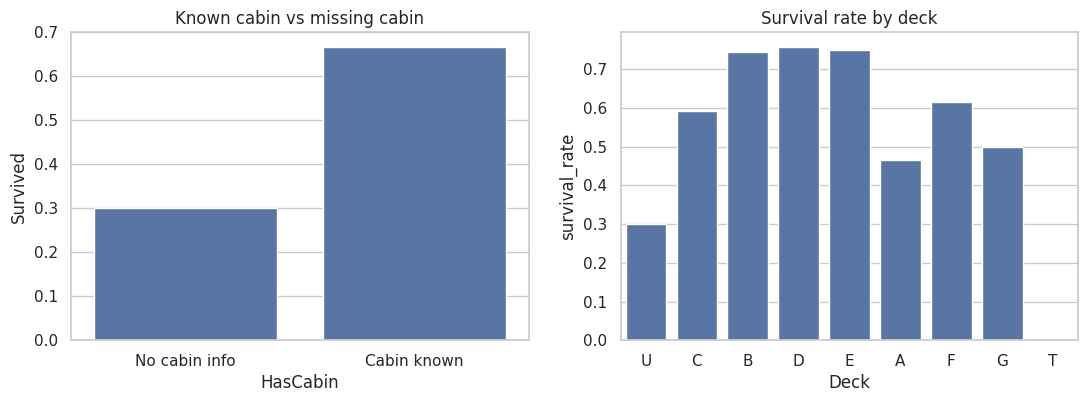

In [9]:
# Cabin availability and deck
deck_stats = (
    eda.groupby("Deck")
       .agg(passengers=("PassengerId", "count"),
            survival_rate=("Survived", "mean"))
       .sort_values("passengers", ascending=False)
)

display(deck_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=eda.groupby("HasCabin")["Survived"].mean().reset_index(),
    x="HasCabin", y="Survived", ax=axes[0]
)
axes[0].set_title("Known cabin vs missing cabin")
axes[0].set_xticklabels(["No cabin info", "Cabin known"])

sns.barplot(
    data=deck_stats.reset_index(),
    x="Deck", y="survival_rate", ax=axes[1]
)
axes[1].set_title("Survival rate by deck")
plt.show()

<div style="background:#f8fafc; padding:18px 22px; border-radius:14px; border:1px solid #e5e7eb; margin-top: 8px;">
  <div style="font-size:18px; margin-bottom:8px;"><b>Visual context: deck structure</b></div>
  <div style="margin-bottom:12px;">
    Cabin information is incomplete in the dataset, but when it exists it hints at spatial position on the ship. That is why
    deck-related features can be useful even with substantial missingness.
  </div>
  <img src="https://commons.wikimedia.org/wiki/Special:FilePath/Titanic%20Boat%20Deck%20plan%20with%20lifeboats.png"
       alt="Titanic boat deck plan with lifeboats"
       width="100%"
       style="border-radius: 12px;"/>
  <div style="text-align:center; color:#6b7280; font-size:12px; margin-top:8px;">
    Titanic boat deck plan with lifeboats
  </div>
</div>

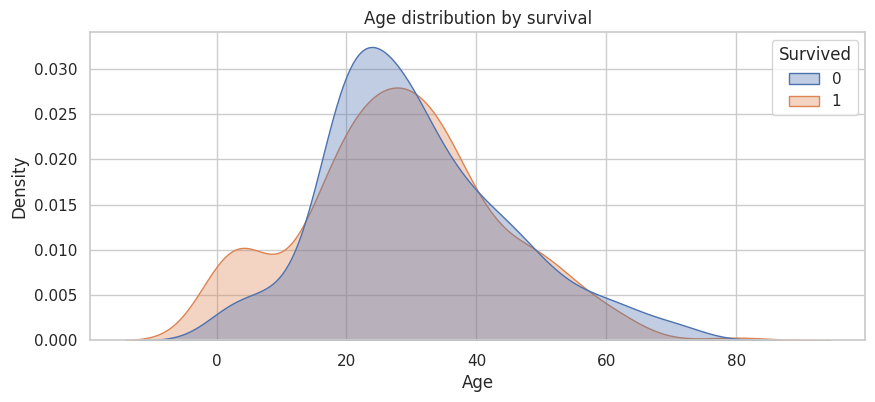

In [10]:
# Age distribution by survival
fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(data=eda, x="Age", hue="Survived", fill=True, common_norm=False, alpha=0.35, ax=ax)
ax.set_title("Age distribution by survival")
plt.show()

### Travel-group hypothesis

Family columns capture part of the story, but not all of it.  
Passengers sharing the same ticket may have traveled together even when surnames differ, so ticket groups can reveal coordination, shared cabins, or shared booking status.

,TicketGroupSize,passengers,survival_rate,median_fare_per_person
0,1,547,0.2980,8.0500
1,2,188,0.5745,13.0000
2,3,63,0.6984,11.0000
3,4,44,0.5000,8.5938
4,5,10,0.0000,10.2625
5,6,18,0.0000,6.6146
6,7,21,0.2381,8.0708


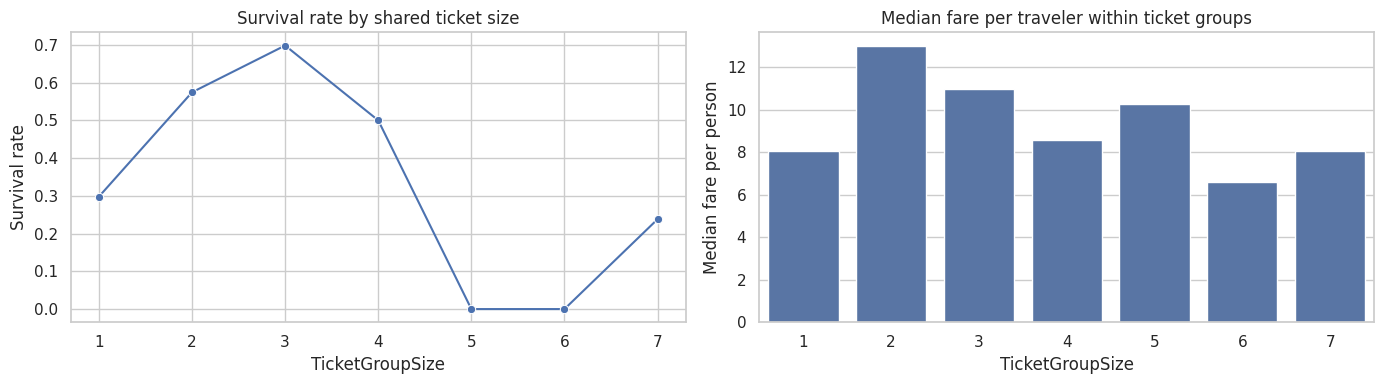

In [11]:
# Ticket-group structure
eda["TicketGroupSize"] = eda.groupby("Ticket")["Ticket"].transform("size")
eda["FarePerTicketPerson"] = eda["Fare"] / eda["TicketGroupSize"].clip(lower=1)

ticket_stats = (
    eda.groupby("TicketGroupSize")
       .agg(passengers=("PassengerId", "count"),
            survival_rate=("Survived", "mean"),
            median_fare_per_person=("FarePerTicketPerson", "median"))
       .reset_index()
       .sort_values("TicketGroupSize")
)

display(ticket_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(
    data=ticket_stats,
    x="TicketGroupSize",
    y="survival_rate",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Survival rate by shared ticket size")
axes[0].set_ylabel("Survival rate")

sns.barplot(
    data=ticket_stats,
    x="TicketGroupSize",
    y="median_fare_per_person",
    ax=axes[1]
)
axes[1].set_title("Median fare per traveler within ticket groups")
axes[1].set_ylabel("Median fare per person")

plt.tight_layout()
plt.show()


### Port-of-embarkation and class hypothesis

Embarkation is often treated as a weak standalone feature.  
It becomes more informative when combined with class, because port may proxy socioeconomic composition and different ticket mixes.

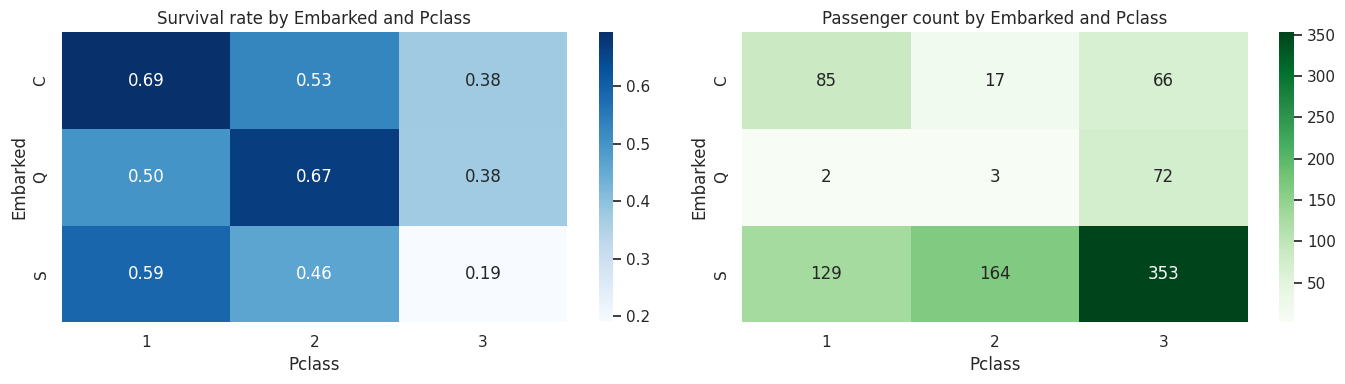

In [12]:
# Embarkation x class
eda["Embarked"] = eda["Embarked"].fillna(eda["Embarked"].mode()[0])

embarked_class_survival = pd.pivot_table(
    eda,
    values="Survived",
    index="Embarked",
    columns="Pclass",
    aggfunc="mean"
)

embarked_class_count = pd.pivot_table(
    eda,
    values="PassengerId",
    index="Embarked",
    columns="Pclass",
    aggfunc="count"
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.heatmap(embarked_class_survival, annot=True, fmt=".2f", cmap="Blues", ax=axes[0])
axes[0].set_title("Survival rate by Embarked and Pclass")

sns.heatmap(embarked_class_count, annot=True, fmt=".0f", cmap="Greens", ax=axes[1])
axes[1].set_title("Passenger count by Embarked and Pclass")

plt.tight_layout()
plt.show()


### Fare and class hypothesis

Raw fare is noisy because class already explains a lot of it.  
A better question is whether **fare still separates outcomes within class**, which would suggest that economic signal remains useful even after `Pclass` is known.

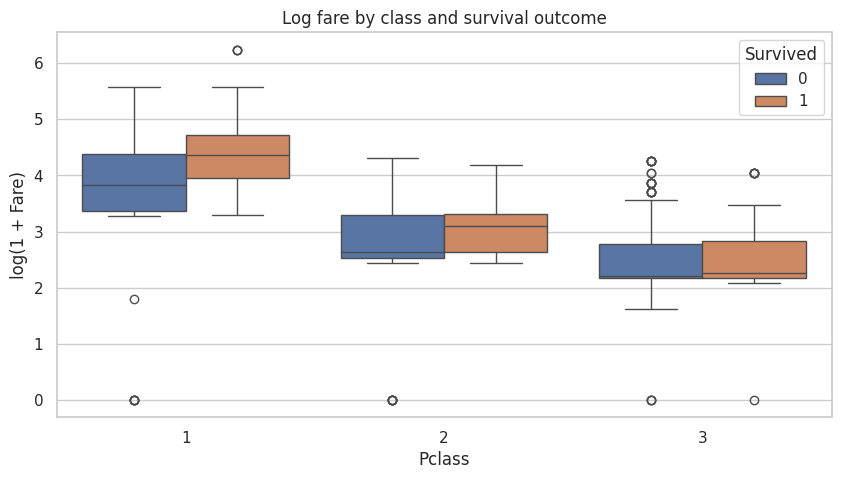

In [13]:
# Fare within class
eda["LogFare"] = np.log1p(eda["Fare"])

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=eda, x="Pclass", y="LogFare", hue="Survived", ax=ax)
ax.set_title("Log fare by class and survival outcome")
ax.set_ylabel("log(1 + Fare)")
plt.show()


### Title and gender hypothesis

Gender alone is powerful, but titles refine it further.  
For example, `Master` identifies boys, while `Mrs` and `Miss` separate adult and unmarried women into distinct social roles.

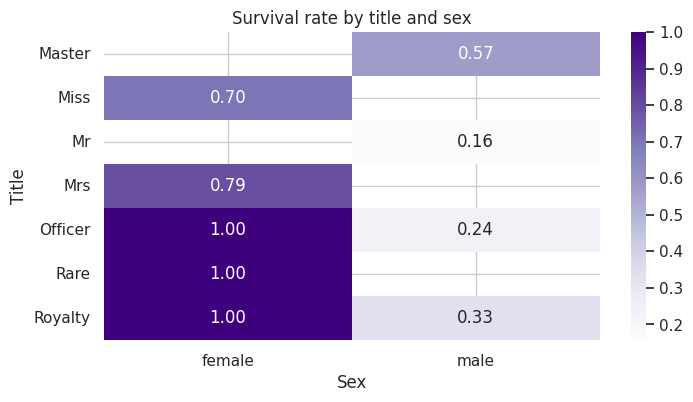

In [14]:
# Title x sex
title_sex_survival = pd.pivot_table(
    eda,
    values="Survived",
    index="Title",
    columns="Sex",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(title_sex_survival, annot=True, fmt=".2f", cmap="Purples", ax=ax)
ax.set_title("Survival rate by title and sex")
plt.show()


<div style="background:#f8fafc; padding:18px 22px; border-radius:14px; border-left:6px solid #0f172a;">

## EDA conclusion

A coherent pattern starts to emerge:

- **Gender mattered**, but class sharply changed how much it mattered.
- **Titles** separate social roles more clearly than names alone.
- **Intermediate family sizes** appear safer than either solitude or very large groups.
- **Cabin and deck information** are too informative to discard, even with many missing values.
- **Ticket-level structure** adds information beyond household counts.
- **Embarkation and fare** become more useful once they are interpreted in context rather than in isolation.

This creates a natural bridge from visual analysis to feature engineering.
</div>

<div style="border-top: 3px solid #0f172a; padding-top: 14px; margin-top: 4px;"></div>

## 4. Feature engineering

The next step is to translate the narrative patterns into variables the models can actually use.

### Identity and status
- extracted title from `Name`
- grouped rare titles into broader social-role categories
- extracted `Deck` from `Cabin`
- created `HasCabin`

### Travel structure
- `FamilySize`, `IsAlone`, `IsLargeFamily`
- `TicketGroupSize`
- `SurnameGroupSize`

### Economic context
- `FarePerPerson`
- fare bins and class-aware interactions

### Missingness-aware variables
- group-aware age imputation
- explicit indicators where absence itself may carry signal

The main principle is not to create as many features as possible, but to create features that correspond to interpretable mechanisms.

In [15]:
# =========================
# 5. Feature engineering
# =========================
def simplify_title(title):
    title_map = {
        "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
        "Lady": "Royalty", "Countess": "Royalty", "Sir": "Royalty",
        "Don": "Royalty", "Dona": "Royalty", "Jonkheer": "Royalty",
        "Capt": "Officer", "Col": "Officer", "Major": "Officer",
        "Dr": "Officer", "Rev": "Officer"
    }
    title = title_map.get(title, title)
    return title if title in {"Mr", "Mrs", "Miss", "Master", "Officer", "Royalty"} else "Rare"

def clean_ticket_prefix(ticket):
    ticket = str(ticket).upper().replace(".", "").replace("/", "").strip()
    prefix = re.sub(r"\d+", "", ticket).replace(" ", "")
    return prefix if prefix else "NUM"

def engineer_features(train_df, test_df):
    train_df = train_df.copy()
    test_df = test_df.copy()

    full = pd.concat([train_df.drop(columns=["Survived"]), test_df], axis=0, ignore_index=True)

    full["TitleRaw"] = full["Name"].apply(extract_title)
    full["Title"] = full["TitleRaw"].apply(simplify_title)

    full["Surname"] = full["Name"].str.extract(r"^([^,]+),", expand=False).fillna("Unknown")
    full["Deck"] = full["Cabin"].fillna("U").astype(str).str[0]
    full["HasCabin"] = full["Cabin"].notna().astype(int)

    full["TicketPrefix"] = full["Ticket"].apply(clean_ticket_prefix)
    full["FamilySize"] = full["SibSp"] + full["Parch"] + 1
    full["IsAlone"] = (full["FamilySize"] == 1).astype(int)
    full["IsLargeFamily"] = (full["FamilySize"] >= 5).astype(int)

    full["TicketGroupSize"] = full.groupby("Ticket")["Ticket"].transform("size")
    full["SurnameGroupSize"] = full.groupby("Surname")["Surname"].transform("size")

    full["Embarked"] = full["Embarked"].fillna(full["Embarked"].mode()[0])

    full["Fare"] = full["Fare"].fillna(
        full.groupby(["Pclass", "Embarked"])["Fare"].transform("median")
    )

    full["FarePerTicketPerson"] = full["Fare"] / full["TicketGroupSize"].clip(lower=1)
    full["FarePerFamilyMember"] = full["Fare"] / full["FamilySize"].clip(lower=1)

    full["AgeMissing"] = full["Age"].isna().astype(int)
    full["Age"] = full["Age"].fillna(
        full.groupby(["Sex", "Pclass", "Title"])["Age"].transform("median")
    )
    full["Age"] = full["Age"].fillna(
        full.groupby(["Sex", "Pclass"])["Age"].transform("median")
    )
    full["Age"] = full["Age"].fillna(full["Age"].median())

    full["AgeBand"] = pd.cut(
        full["Age"],
        bins=[0, 5, 12, 18, 30, 45, 60, 100],
        labels=["Baby", "Child", "Teen", "YoungAdult", "Adult", "Mature", "Senior"],
        include_lowest=True
    ).astype(str)

    full["FareBand"] = pd.qcut(
        full["Fare"].rank(method="first"),
        5,
        labels=["VeryLow", "Low", "Mid", "High", "VeryHigh"]
    ).astype(str)

    full["WomanOrChild"] = ((full["Sex"] == "female") | (full["Age"] < 16)).astype(int)
    full["Pclass_Sex"] = full["Pclass"].astype(str) + "_" + full["Sex"]
    full["Pclass_Embarked"] = full["Pclass"].astype(str) + "_" + full["Embarked"]
    full["Title_Pclass"] = full["Title"].astype(str) + "_" + full["Pclass"].astype(str)
    full["Surname_Pclass"] = full["Surname"].astype(str) + "_" + full["Pclass"].astype(str)

    train_fe = full.iloc[:len(train_df)].copy()
    test_fe = full.iloc[len(train_df):].copy()

    train_fe["Survived"] = train_df["Survived"].values
    return train_fe, test_fe

train_fe, test_fe = engineer_features(train, test)

print("Engineered train shape:", train_fe.shape)
print("Engineered test shape :", test_fe.shape)
display(train_fe.head())

Engineered train shape: (891, 33)
Engineered test shape : (418, 32)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,TitleRaw,Title,Surname,Deck,HasCabin,TicketPrefix,FamilySize,IsAlone,IsLargeFamily,TicketGroupSize,SurnameGroupSize,FarePerTicketPerson,FarePerFamilyMember,AgeMissing,AgeBand,FareBand,WomanOrChild,Pclass_Sex,Pclass_Embarked,Title_Pclass,Surname_Pclass,Survived
0,1,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S,Mr,Mr,Braund,U,0,A,2,0,0,1,2,7.2500,3.6250,0,YoungAdult,VeryLow,0,3_male,3_S,Mr_3,Braund_3,0
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C,Mrs,Mrs,Cumings,C,1,PC,2,0,0,2,2,35.6416,35.6416,0,Adult,VeryHigh,1,1_female,1_C,Mrs_1,Cumings_1,1
2,3,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Miss,Heikkinen,U,0,STONO,1,1,0,1,1,7.9250,7.9250,0,YoungAdult,Low,1,3_female,3_S,Miss_3,Heikkinen_3,1
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S,Mrs,Mrs,Futrelle,C,1,NUM,2,0,0,2,2,26.5500,26.5500,0,Adult,VeryHigh,1,1_female,1_S,Mrs_1,Futrelle_1,1
4,5,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S,Mr,Mr,Allen,U,0,NUM,1,1,0,1,2,8.0500,8.0500,0,Adult,Low,0,3_male,3_S,Mr_3,Allen_3,0


### Engineered-feature correlation scan

Before fitting models, it is useful to inspect which engineered numeric features align most strongly with the target and with each other.
This helps separate genuinely new signal from features that mostly repackage the same information.

Skipping columns not yet available: ['Title_Pclass_prior', 'Surname_Pclass_prior', 'TicketPrefix_prior']


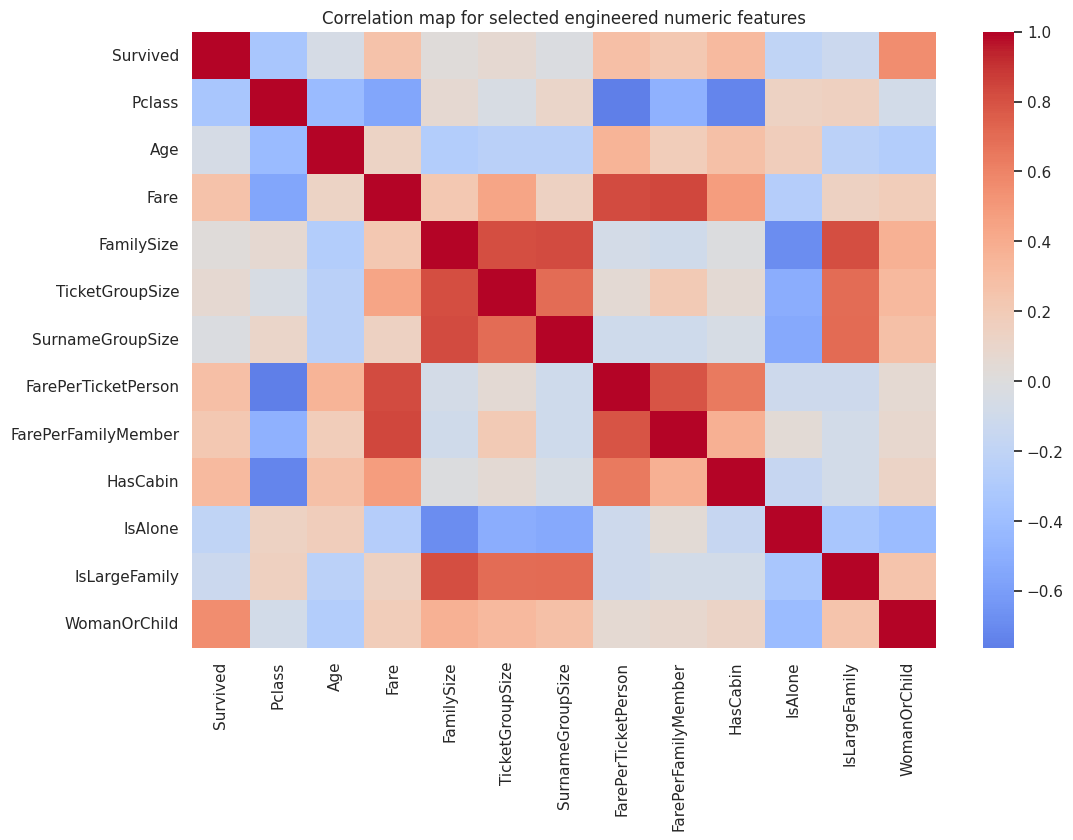

,correlation_with_survived
Survived,1.0000
WomanOrChild,0.5582
HasCabin,0.3169
FarePerTicketPerson,0.2883
Fare,0.2573
FarePerFamilyMember,0.2216
TicketGroupSize,0.0650
FamilySize,0.0166
SurnameGroupSize,-0.0255
Age,-0.0596


In [16]:
corr_cols = [
    "Survived", "Pclass", "Age", "Fare", "FamilySize", "TicketGroupSize",
    "SurnameGroupSize", "FarePerTicketPerson", "FarePerFamilyMember",
    "HasCabin", "IsAlone", "IsLargeFamily", "WomanOrChild",
    "Title_Pclass_prior", "Surname_Pclass_prior", "TicketPrefix_prior"
]

available_corr_cols = [col for col in corr_cols if col in train_fe.columns]
missing_corr_cols = [col for col in corr_cols if col not in train_fe.columns]

if missing_corr_cols:
    print("Skipping columns not yet available:", missing_corr_cols)

corr_view = train_fe[available_corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_view, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation map for selected engineered numeric features")
plt.show()

if "Survived" in corr_view.columns:
    display(
        corr_view["Survived"]
        .sort_values(ascending=False)
        .to_frame("correlation_with_survived")
    )


## 5. Leakage-safe target priors

Some groupings clearly carry survival information:

- title + class,
- surname + class,
- ticket prefix.

Using direct target means from the full training data would leak information into validation folds, so these priors are created in an **out-of-fold** way for the training set and only then transferred to the test set.

This keeps the features informative without letting the model peek at future labels.

In [17]:
def add_oof_target_priors(train_df, test_df, target, group_cols, n_splits=5, smoothing=10):
    train_df = train_df.copy()
    test_df = test_df.copy()

    global_mean = target.mean()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

    for col in group_cols:
        oof_values = pd.Series(index=train_df.index, dtype=float)

        for tr_idx, val_idx in skf.split(train_df, target):
            x_tr = train_df.iloc[tr_idx]
            y_tr = target.iloc[tr_idx]

            stats = (
                pd.DataFrame({col: x_tr[col], "target": y_tr})
                .groupby(col)["target"]
                .agg(["mean", "count"])
            )

            stats["encoded"] = (
                stats["mean"] * stats["count"] + global_mean * smoothing
            ) / (stats["count"] + smoothing)

            oof_values.iloc[val_idx] = (
                train_df.iloc[val_idx][col].map(stats["encoded"]).fillna(global_mean)
            )

        train_df[f"{col}_prior"] = oof_values

        full_stats = (
            pd.DataFrame({col: train_df[col], "target": target})
            .groupby(col)["target"]
            .agg(["mean", "count"])
        )

        full_stats["encoded"] = (
            full_stats["mean"] * full_stats["count"] + global_mean * smoothing
        ) / (full_stats["count"] + smoothing)

        test_df[f"{col}_prior"] = test_df[col].map(full_stats["encoded"]).fillna(global_mean)

    return train_df, test_df

target = train["Survived"]

prior_cols = ["Title_Pclass", "Surname_Pclass", "TicketPrefix"]
train_fe, test_fe = add_oof_target_priors(
    train_fe,
    test_fe,
    target=target,
    group_cols=prior_cols,
    n_splits=5,
    smoothing=12
)

display(train_fe[[c for c in train_fe.columns if c.endswith("_prior")]].head())

,Title_Pclass_prior,Surname_Pclass_prior,TicketPrefix_prior
0,0.1235,0.3543,0.1887
1,0.8175,0.3838,0.5896
2,0.5231,0.3838,0.3788
3,0.8135,0.3543,0.3905
4,0.1314,0.3838,0.3756


<div style="border-top: 3px solid #0f172a; padding-top: 14px; margin-top: 4px;"></div>

## 6. Modeling setup

Two complementary model families are compared:

1. **Regularized Logistic Regression**  
   Useful for stable linear structure after careful encoding and scaling.

2. **CatBoost**  
   Useful for interactions, non-linearities, and mixed feature types with less manual preprocessing.

A random forest baseline is also included as a reference point.

The purpose is not only to chase a score, but to compare different inductive views of the same problem and combine them when they capture different parts of the signal.

In [18]:
# Feature lists
target = train["Survived"]

categorical_features = [
    "Sex", "Embarked", "Title", "Deck", "TicketPrefix",
    "AgeBand", "FareBand", "Pclass_Sex", "Pclass_Embarked", "Title_Pclass"
]

numeric_features = [
    "Pclass", "Age", "SibSp", "Parch", "Fare",
    "HasCabin", "FamilySize", "IsAlone", "IsLargeFamily",
    "TicketGroupSize", "SurnameGroupSize",
    "FarePerTicketPerson", "FarePerFamilyMember",
    "AgeMissing", "WomanOrChild",
    "Title_Pclass_prior", "Surname_Pclass_prior", "TicketPrefix_prior"
]

model_features = categorical_features + numeric_features

In [19]:
# Logistic Regression pipeline
logreg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)

logreg_model = Pipeline([
    ("preprocessor", logreg_preprocessor),
    ("classifier", LogisticRegression(
        C=0.8,
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

# Random forest baseline (optional but often useful for comparison)
rf_model = Pipeline([
    ("preprocessor", logreg_preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=6,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ))
])

# CatBoost works directly on mixed feature types
catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    l2_leaf_reg=6,
    min_data_in_leaf=5,
    loss_function="Logloss",
    eval_metric="Accuracy",
    bootstrap_type="Bernoulli",
    subsample=0.85,
    random_seed=RANDOM_STATE,
    verbose=False
)

,Model,CV Accuracy Mean,CV Accuracy Std
2,CatBoost,0.8417,0.0128
0,Logistic Regression,0.8361,0.0169
1,Random Forest,0.8361,0.0146


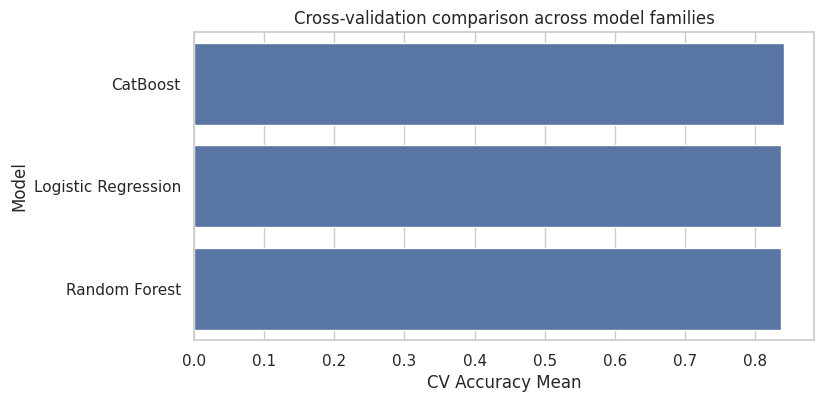

In [20]:
# =========================
# 8. Cross-validation
# =========================
def evaluate_sklearn_model(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    return scores.mean(), scores.std()

def evaluate_catboost_model(model, X, y, cat_cols, cv):
    scores = []

    cat_indices = [X.columns.get_loc(col) for col in cat_cols]

    for tr_idx, val_idx in cv.split(X, y):
        X_tr = X.iloc[tr_idx]
        X_val = X.iloc[val_idx]
        y_tr = y.iloc[tr_idx]
        y_val = y.iloc[val_idx]

        clf = clone(model)
        clf.fit(X_tr, y_tr, cat_features=cat_indices)

        pred = clf.predict(X_val).astype(int).ravel()
        scores.append(accuracy_score(y_val, pred))

    return np.mean(scores), np.std(scores)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

benchmark_rows = []

logreg_mean, logreg_std = evaluate_sklearn_model(
    logreg_model,
    train_fe[model_features],
    target,
    cv
)
benchmark_rows.append(("Logistic Regression", logreg_mean, logreg_std))

rf_mean, rf_std = evaluate_sklearn_model(
    rf_model,
    train_fe[model_features],
    target,
    cv
)
benchmark_rows.append(("Random Forest", rf_mean, rf_std))

cat_mean, cat_std = evaluate_catboost_model(
    catboost_model,
    train_fe[model_features],
    target,
    categorical_features,
    cv
)
benchmark_rows.append(("CatBoost", cat_mean, cat_std))

benchmark = pd.DataFrame(
    benchmark_rows,
    columns=["Model", "CV Accuracy Mean", "CV Accuracy Std"]
).sort_values("CV Accuracy Mean", ascending=False)

display(benchmark)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=benchmark, x="CV Accuracy Mean", y="Model", ax=ax)
ax.set_title("Cross-validation comparison across model families")
plt.show()


## 7. OOF predictions and blending

Rather than forcing a single winner, the final prediction blends two different views of the data:

- a **linear model** that benefits from clean encoded structure,
- a **boosted tree model** that captures interactions more naturally.

The blend is selected on out-of-fold predictions rather than on the test set.

In [21]:
def get_oof_and_test_probs_sklearn(model, X_train, y_train, X_test, cv):
    oof = np.zeros(len(X_train))
    test_probs = np.zeros(len(X_test))

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[tr_idx]

        clf = clone(model)
        clf.fit(X_tr, y_tr)

        oof[val_idx] = clf.predict_proba(X_val)[:, 1]
        test_probs += clf.predict_proba(X_test)[:, 1] / cv.get_n_splits()

    return oof, test_probs

def get_oof_and_test_probs_catboost(model, X_train, y_train, X_test, cat_cols, cv):
    oof = np.zeros(len(X_train))
    test_probs = np.zeros(len(X_test))
    cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr = y_train.iloc[tr_idx]

        clf = clone(model)
        clf.fit(X_tr, y_tr, cat_features=cat_indices)

        oof[val_idx] = clf.predict_proba(X_val)[:, 1]
        test_probs += clf.predict_proba(X_test)[:, 1] / cv.get_n_splits()

    return oof, test_probs

X_train_model = train_fe[model_features].copy()
X_test_model = test_fe[model_features].copy()

oof_logreg, test_logreg = get_oof_and_test_probs_sklearn(
    logreg_model, X_train_model, target, X_test_model, cv
)

oof_cat, test_cat = get_oof_and_test_probs_catboost(
    catboost_model, X_train_model, target, X_test_model, categorical_features, cv
)

,catboost_weight,logreg_weight,oof_accuracy
0,0.5000,0.5000,0.8462
2,0.6000,0.4000,0.8462
5,0.7500,0.2500,0.8451
6,0.8000,0.2000,0.8451
1,0.5500,0.4500,0.8440
7,0.8500,0.1500,0.8440
8,0.9000,0.1000,0.8440
4,0.7000,0.3000,0.8429
3,0.6500,0.3500,0.8429


Best blend: 0.50 * CatBoost + 0.50 * LogisticRegression


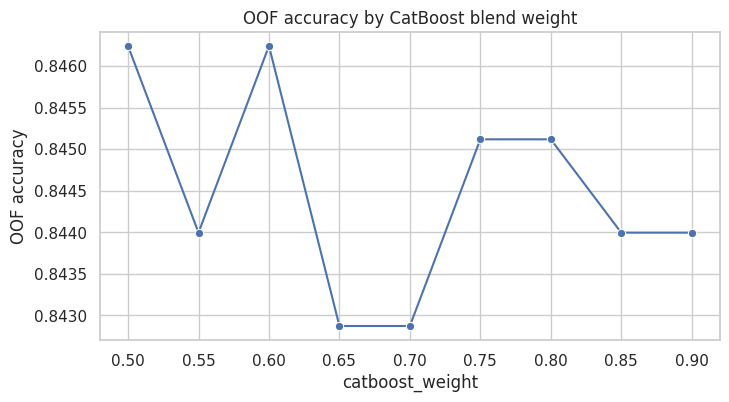

In [22]:
# Search for a good blend weight
blend_results = []

for w_cat in np.arange(0.50, 0.91, 0.05):
    w_logreg = 1 - w_cat
    blend_oof = w_cat * oof_cat + w_logreg * oof_logreg
    blend_pred = (blend_oof >= 0.5).astype(int)
    score = accuracy_score(target, blend_pred)
    blend_results.append((w_cat, w_logreg, score))

blend_results = pd.DataFrame(
    blend_results,
    columns=["catboost_weight", "logreg_weight", "oof_accuracy"]
).sort_values("oof_accuracy", ascending=False)

display(blend_results)

best_cat_weight = blend_results.iloc[0]["catboost_weight"]
best_logreg_weight = blend_results.iloc[0]["logreg_weight"]

print(f"Best blend: {best_cat_weight:.2f} * CatBoost + {best_logreg_weight:.2f} * LogisticRegression")

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=blend_results.sort_values("catboost_weight"), x="catboost_weight", y="oof_accuracy", marker="o", ax=ax)
ax.set_title("OOF accuracy by CatBoost blend weight")
ax.set_ylabel("OOF accuracy")
plt.show()


In [23]:
# Final blended probabilities
final_test_probs = best_cat_weight * test_cat + best_logreg_weight * test_logreg
final_test_pred = (final_test_probs >= 0.5).astype(int)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": final_test_pred
})

submission.to_csv("submission_titanic_story_blend.csv", index=False)
display(submission.head())

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## 8. CatBoost feature importance

Even though the final submission is blended, CatBoost feature importance remains useful for understanding which engineered signals dominate the model's decisions.

,feature,importance
2,Title,8.7488
7,Pclass_Sex,8.2673
26,Surname_Pclass_prior,8.1719
24,WomanOrChild,7.3310
25,Title_Pclass_prior,5.9881
11,Age,5.6755
6,FareBand,5.5637
8,Pclass_Embarked,5.2941
5,AgeBand,4.9962
22,FarePerFamilyMember,4.4883


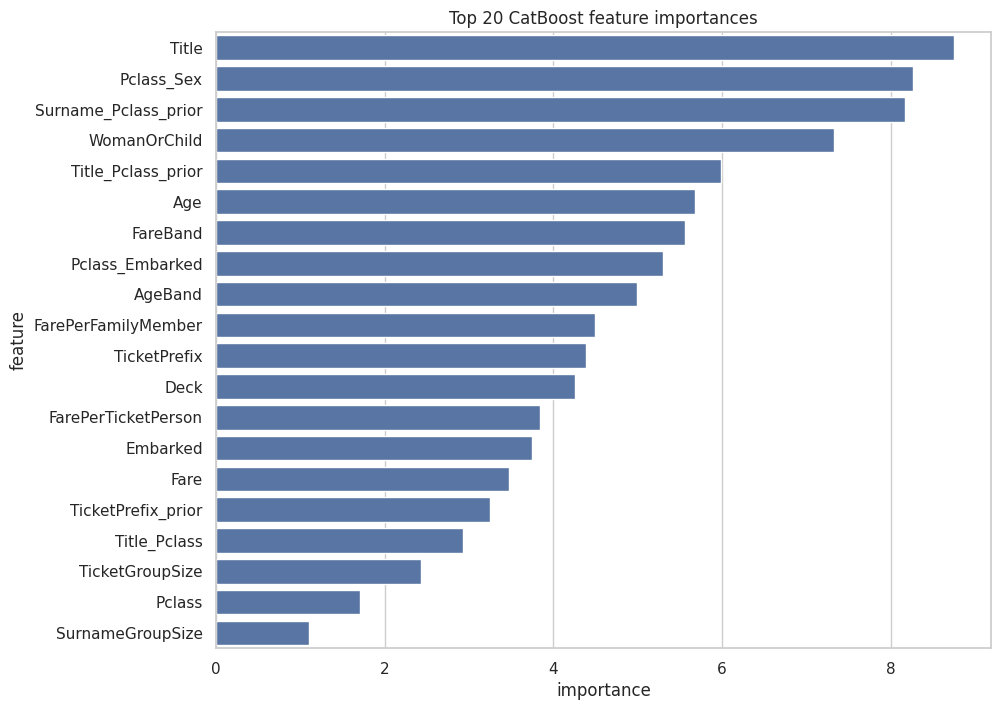

In [24]:
final_catboost = clone(catboost_model)
final_catboost.fit(
    X_train_model,
    target,
    cat_features=[X_train_model.columns.get_loc(col) for col in categorical_features]
)

feature_importance = pd.DataFrame({
    "feature": X_train_model.columns,
    "importance": final_catboost.get_feature_importance()
}).sort_values("importance", ascending=False)

display(feature_importance.head(20))

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(
    data=feature_importance.head(20),
    x="importance",
    y="feature",
    ax=ax
)
ax.set_title("Top 20 CatBoost feature importances")
plt.show()

<div style="border-top: 3px solid #0f172a; padding-top: 14px; margin-top: 4px;"></div>

## 9. Error analysis

The most revealing mistakes are the confident ones.

They often point to one of three things:

1. a missing interaction,
2. a genuinely ambiguous passenger profile,
3. noise or hard limits in what can be recovered from the available columns.

Below, the blended out-of-fold probabilities are used to inspect these hard cases.

,PassengerId,Name,Sex,Age,Pclass,Fare,Embarked,Title,Deck,FamilySize,TicketGroupSize,true_target,oof_probability,oof_prediction,correct,confidence_gap
146,147,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0000,3,7.7958,S,Mr,U,1,1,1,0.0178,0,0,0.4822
570,571,"Harris, Mr. George",male,62.0000,2,10.5000,S,Mr,U,1,1,1,0.0191,0,0,0.4809
177,178,"Isham, Miss. Ann Elizabeth",female,50.0000,1,28.7125,C,Miss,C,1,1,0,0.9790,1,0,0.4790
297,298,"Allison, Miss. Helen Loraine",female,2.0000,1,151.5500,S,Miss,C,4,6,0,0.9727,1,0,0.4727
68,69,"Andersson, Miss. Erna Alexandra",female,17.0000,3,7.9250,S,Miss,U,7,1,1,0.0309,0,0,0.4691
498,499,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,151.5500,S,Mrs,C,4,6,0,0.9652,1,0,0.4652
772,773,"Mack, Mrs. (Mary)",female,57.0000,2,10.5000,S,Mrs,E,1,2,0,0.9482,1,0,0.4482
312,313,"Lahtinen, Mrs. William (Anna Sylfven)",female,26.0000,2,26.0000,S,Mrs,U,3,2,0,0.9453,1,0,0.4453
357,358,"Funk, Miss. Annie Clemmer",female,38.0000,2,13.0000,S,Miss,U,1,1,0,0.9433,1,0,0.4433
17,18,"Williams, Mr. Charles Eugene",male,30.0000,2,13.0000,S,Mr,U,1,1,1,0.0589,0,0,0.4411


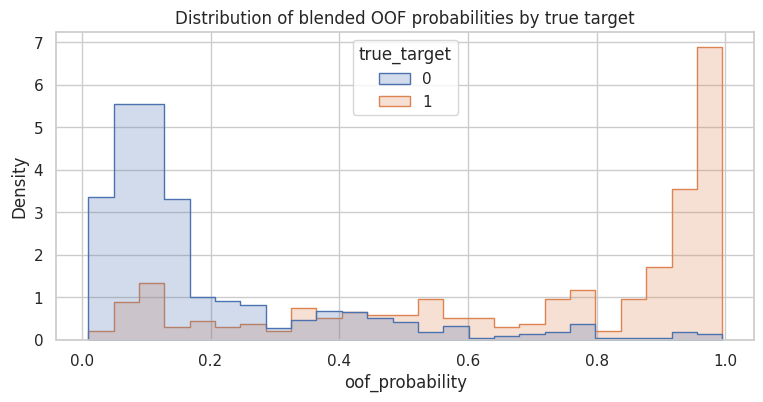

In [25]:
train_error_view = train_fe[[
    "PassengerId", "Name", "Sex", "Age", "Pclass", "Fare", "Embarked",
    "Title", "Deck", "FamilySize", "TicketGroupSize"
]].copy()

train_error_view["true_target"] = target.values
train_error_view["oof_probability"] = best_cat_weight * oof_cat + best_logreg_weight * oof_logreg
train_error_view["oof_prediction"] = (train_error_view["oof_probability"] >= 0.5).astype(int)
train_error_view["correct"] = (train_error_view["true_target"] == train_error_view["oof_prediction"]).astype(int)
train_error_view["confidence_gap"] = np.abs(train_error_view["oof_probability"] - 0.5)

hard_cases = (
    train_error_view.query("correct == 0")
    .sort_values("confidence_gap", ascending=False)
    .head(20)
)

display(hard_cases)

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=train_error_view, x="oof_probability", hue="true_target", bins=25, element="step", stat="density", common_norm=False, ax=ax)
ax.set_title("Distribution of blended OOF probabilities by true target")
plt.show()


### Why these errors matter

When a model is wrong with high confidence, the row is often especially informative:

- a passenger may combine signals from several conflicting groups,
- a strong class or gender signal may be overturned by family or ticket context,
- the observed outcome may reflect chaotic event-level factors that the table cannot capture.

This is useful not only for prediction, but for understanding the remaining limits of the dataset itself.

<div style="border-top: 3px solid #0f172a; padding-top: 14px; margin-top: 4px;"></div>

## 10. Final conclusions

### Main patterns
- social-role features extracted from names are highly informative;
- class-aware interaction features remain central;
- ticket and surname group signals add structure beyond standard family features;
- cabin/deck information is worth keeping despite missingness;
- blending linear and non-linear models improves robustness.

### Substantive interpretation
The dataset repeatedly suggests that survival was shaped by layered structure rather than by single variables.
Gender mattered, but its effect was filtered through class, age, access, and group context. The strongest notebook features are therefore not random engineering tricks:
they are compressed representations of social position and travel organization.

### Modeling interpretation
The best-performing setup combines:
- interpretable linear structure,
- flexible non-linear interactions,
- leakage-safe group priors.

That combination captures both broad regularities and the local exceptions that matter in this dataset.

## 11. Additional experiments worth testing

Several extensions remain promising:

- threshold tuning by passenger subgroup,
- a small stacking layer above the base models,
- surname-level conflict rules for families split across outcomes,
- deck-aware interaction features using age and fare together,
- calibrated probabilities for cleaner interpretation of uncertainty.

The current pipeline is already strong, but the remaining error cases suggest that a little more hierarchical structure could still help.